In [1]:
import platform
platform.platform()

'macOS-15.6.1-arm64-arm-64bit'

In [2]:
import sys
sys.version

'3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]'

In [3]:
import matplotlib
matplotlib.__version__

'3.10.8'

In [4]:
import matplotlib.pyplot as plt

In [5]:
import pandas as pd
pd.__version__

'2.3.3'

In [6]:
df_28 = pd.read_csv("../1_28descriptors/knn_28d.csv")
df_mordred = pd.read_csv("../2_Mordred/knn_mordred.csv")
df_rdkit = pd.read_csv("../3_RDKit/knn_rdkit.csv")
df_ecfp = pd.read_csv("../4_ECFP/knn_ecfp.csv")

In [7]:
df_28 = df_28[df_28["k"] % 2 == 1]
df_28

,k,Accuracy,Precision,Recall,F1
0,1,0.878378,0.791667,0.826087,0.808511
2,3,0.878378,0.791667,0.826087,0.808511
4,5,0.837838,0.739130,0.739130,0.739130
6,7,0.783784,0.666667,0.608696,0.636364
8,9,0.770270,0.650000,0.565217,0.604651
10,11,0.756757,0.619048,0.565217,0.590909
12,13,0.770270,0.650000,0.565217,0.604651
14,15,0.783784,0.684211,0.565217,0.619048


In [8]:
df_mordred = df_mordred[df_mordred["k"] % 2 == 1]
df_mordred

,k,Accuracy,Precision,Recall,F1
0,1,0.756757,0.586207,0.739130,0.653846
2,3,0.783784,0.629630,0.739130,0.680000
4,5,0.743243,0.583333,0.608696,0.595745
6,7,0.743243,0.600000,0.521739,0.558140
8,9,0.729730,0.565217,0.565217,0.565217
10,11,0.729730,0.571429,0.521739,0.545455
12,13,0.716216,0.550000,0.478261,0.511628
14,15,0.729730,0.571429,0.521739,0.545455


In [9]:
df_rdkit = df_rdkit[df_rdkit["k"] % 2 == 1]
df_rdkit

,k,Accuracy,Precision,Recall,F1
0,1,0.756757,0.600000,0.652174,0.625000
2,3,0.756757,0.580645,0.782609,0.666667
4,5,0.716216,0.535714,0.652174,0.588235
6,7,0.648649,0.440000,0.478261,0.458333
8,9,0.621622,0.407407,0.478261,0.440000
10,11,0.635135,0.423077,0.478261,0.448980
12,13,0.662162,0.458333,0.478261,0.468085
14,15,0.702703,0.521739,0.521739,0.521739


In [10]:
df_ecfp = df_ecfp[df_ecfp["k"] % 2 == 1]
df_ecfp

,k,Accuracy,Precision,Recall,F1
0,1,0.770270,0.600000,0.782609,0.679245
2,3,0.824324,0.656250,0.913043,0.763636
4,5,0.824324,0.692308,0.782609,0.734694
6,7,0.756757,0.619048,0.565217,0.590909
8,9,0.716216,0.550000,0.478261,0.511628
10,11,0.702703,0.523810,0.478261,0.500000
12,13,0.702703,0.526316,0.434783,0.476190
14,15,0.743243,0.625000,0.434783,0.512821


In [11]:
label = ["28 descriptors", "Mordred descriptors", "RDKit descriptors", "ECFP"]

In [12]:
def figure(df1, df2, df3, df4, label, column, title, png):
    k = df1["k"]
    y1 = df1[column]
    y2 = df2[column]
    y3 = df3[column]
    y4 = df4[column]

    fig = plt.figure()
    ax = fig.add_subplot()

    p1 = ax.plot(k, y1, label=label[0],
                 linewidth=1, linestyle="solid", markersize=2, marker="o",
                 c="#ff4b00")
    p2 = ax.plot(k, y2, label=label[1],
                 linewidth=1, linestyle="dashed", markersize=2, marker="o",
                 c="#005aff")
    p3 = ax.plot(k, y3, label=label[2],
                 linewidth=1, linestyle="dashdot", markersize=2, marker="o",
                 c="#4dc4ff")
    p4 = ax.plot(k, y4, label=label[3],
                 linewidth=1, linestyle="dotted", markersize=2, marker="o",
                 c="#03af7a")

    ax.legend(loc="lower right", fontsize=12)

    ax.set_xlabel("k", fontsize=15)
    ax.set_ylabel("Score", fontsize=15)
    ax.set_title(title, fontsize=20)

    plt.xticks(range(1, 16, 2))
    plt.yticks([x / 10 for x in range(11)])

    plt.savefig(png, dpi=300)
    plt.show()


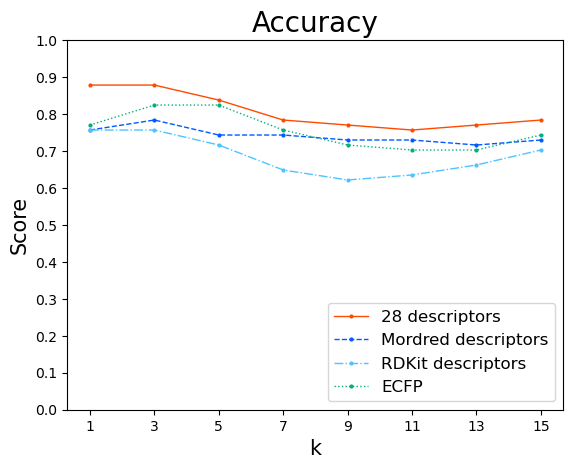

In [13]:
figure(df_28, df_mordred, df_rdkit, df_ecfp, label,
       "Accuracy", "Accuracy", "accuracy.png")

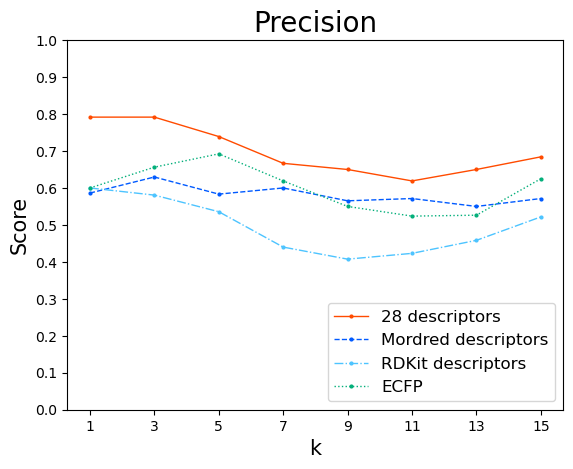

In [14]:
figure(df_28, df_mordred, df_rdkit, df_ecfp, label,
       "Precision", "Precision", "precision.png")

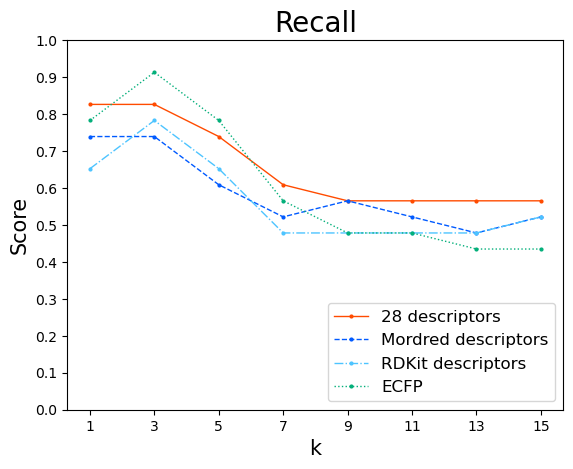

In [15]:
figure(df_28, df_mordred, df_rdkit, df_ecfp, label,
       "Recall", "Recall", "recall.png")

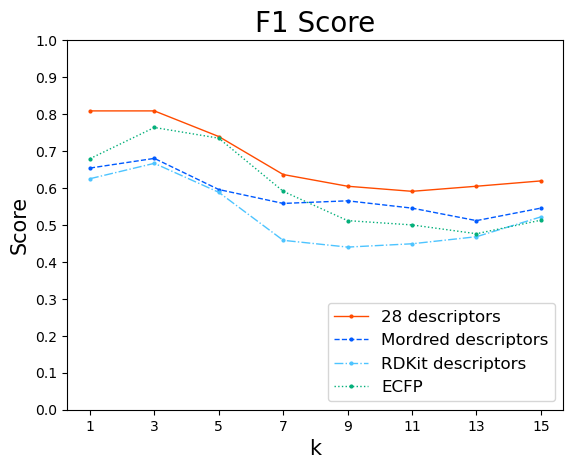

In [16]:
figure(df_28, df_mordred, df_rdkit, df_ecfp, label,
       "F1", "F1 Score", "f1.png")